In [5]:
import os
import shutil

# ⭐ thư mục test gốc
test_root = "./brain-tumor-mri-dataset/Testing"

# ⭐ thư mục ảnh sai (đã lưu từ model)
wrong_root = "./wrong_predictions"

# ⭐ thư mục bạn muốn lưu ảnh đúng
save_correct_root = "correct_predictions"

os.makedirs(save_correct_root, exist_ok=True)

# ==============================
# 1️⃣ Lấy danh sách toàn bộ ảnh sai
# ==============================
wrong_set = set()

for folder in os.listdir(wrong_root):

    folder_path = os.path.join(wrong_root, folder)

    if not os.path.isdir(folder_path):
        continue

    for img in os.listdir(folder_path):
        wrong_set.add(img)

print("Total wrong images:", len(wrong_set))

# ==============================
# 2️⃣ Duyệt toàn bộ ảnh test
# ==============================
total_correct = 0

for class_name in os.listdir(test_root):

    class_path = os.path.join(test_root, class_name)

    if not os.path.isdir(class_path):
        continue

    save_class_folder = os.path.join(save_correct_root, class_name)
    os.makedirs(save_class_folder, exist_ok=True)

    for img in os.listdir(class_path):

        if img not in wrong_set:

            src = os.path.join(class_path, img)
            dst = os.path.join(save_class_folder, img)

            shutil.copy(src, dst)
            total_correct += 1

print("Total correct images copied:", total_correct)

Total wrong images: 89
Total correct images copied: 1511


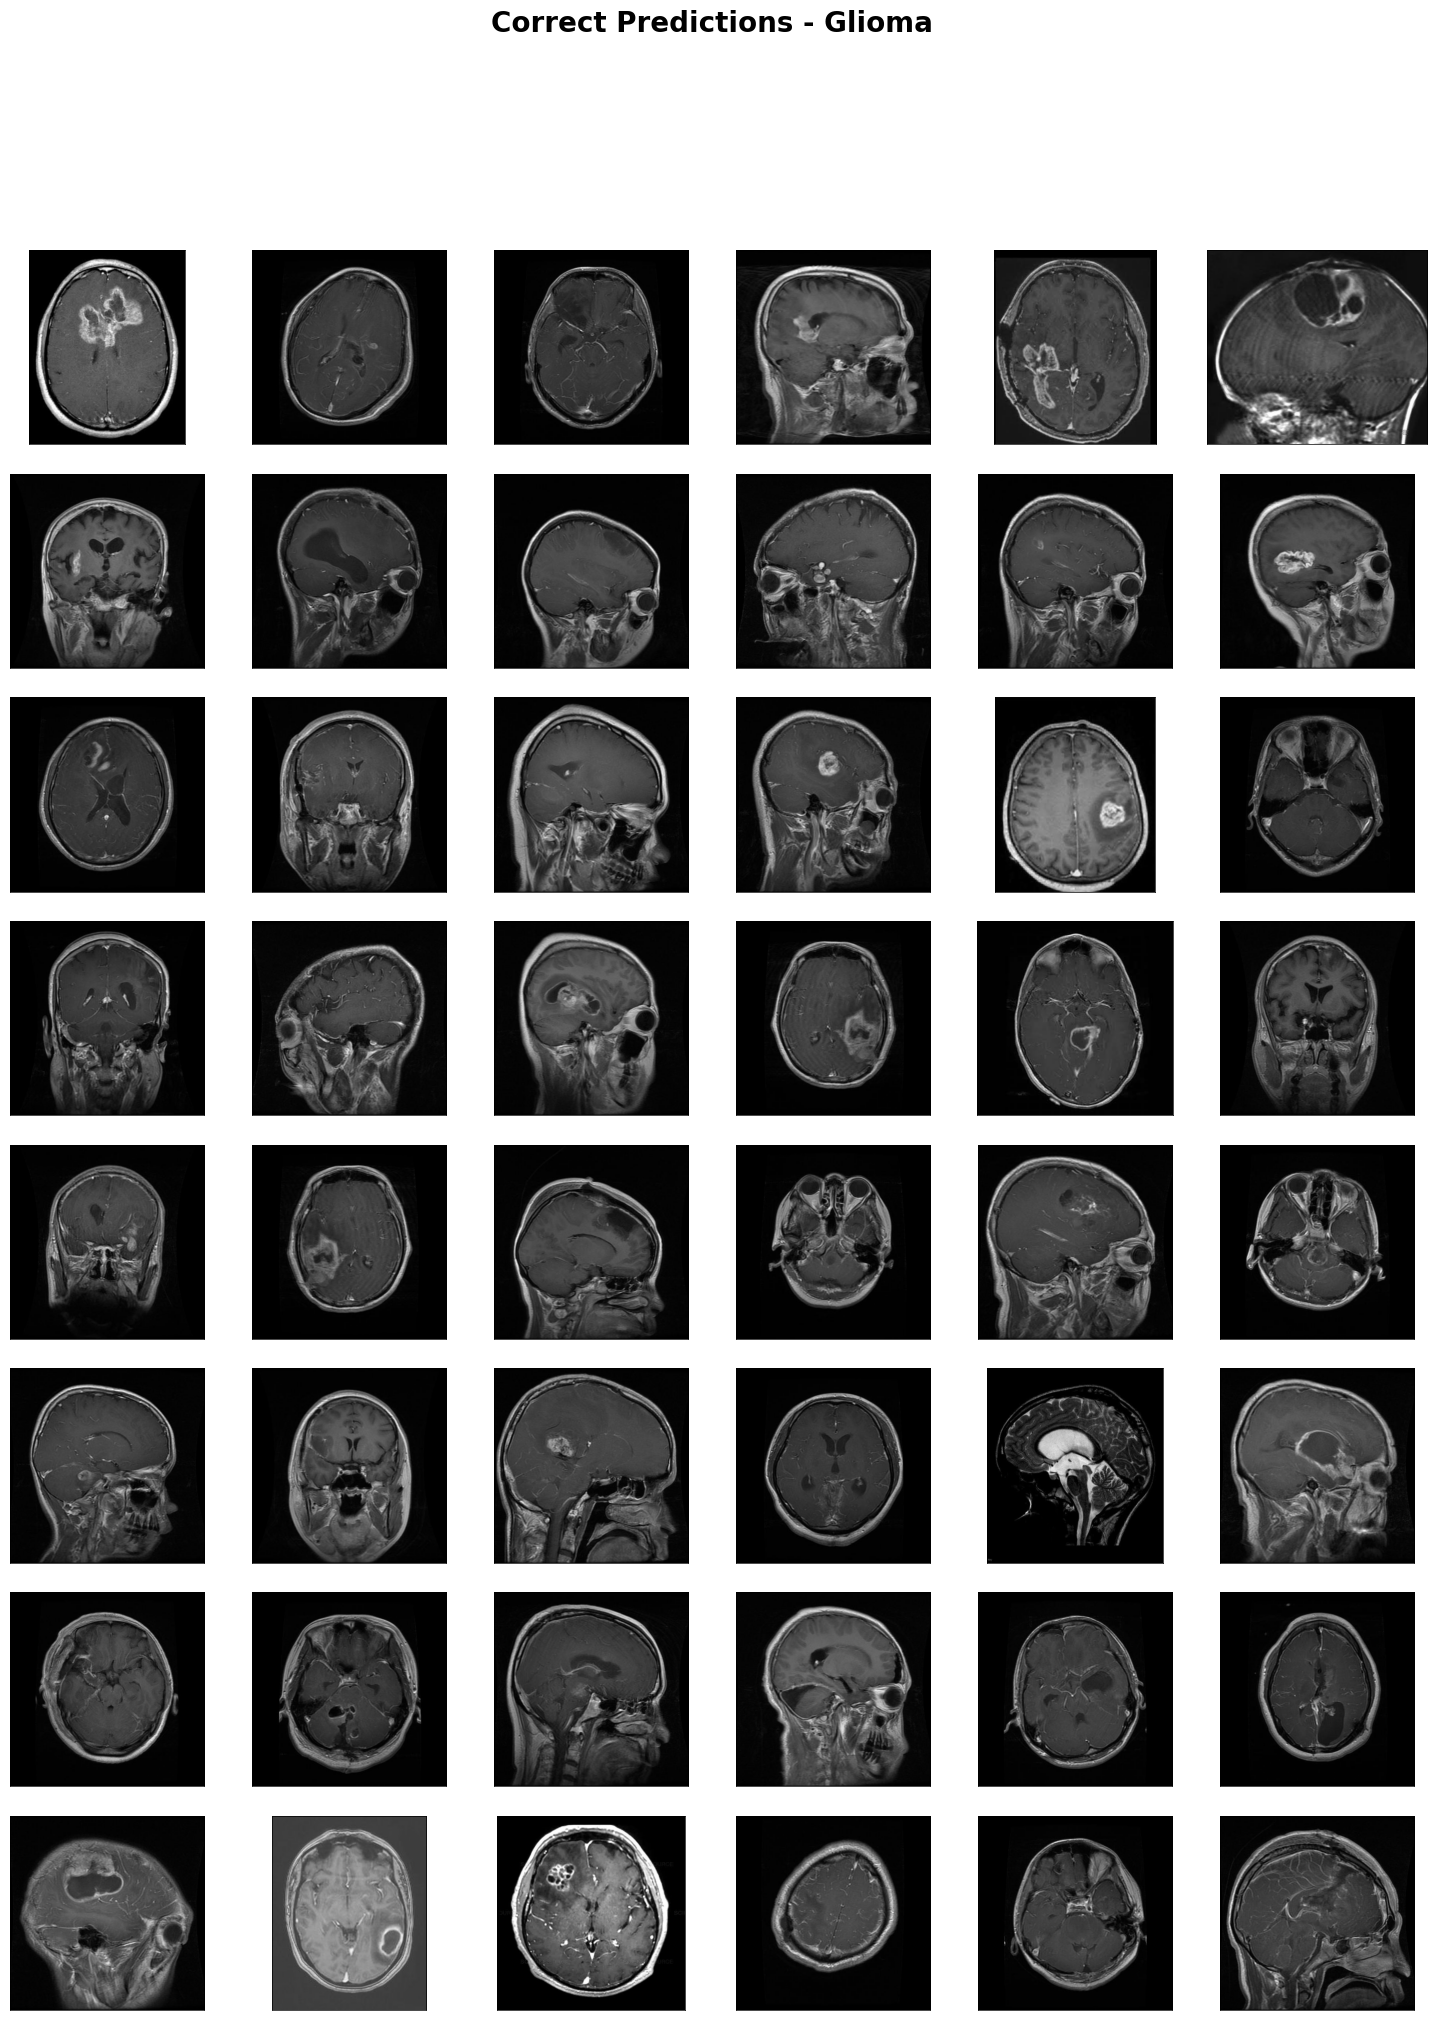

In [ ]:
import os
import math
from PIL import Image
import matplotlib.pyplot as plt

wrong_root = "./correct_predictions/glioma"

cols = 8
max_img = 48

images = os.listdir(wrong_root)[:max_img]
n = len(images)

if n == 0:
    print("Folder không có ảnh")
else:
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(2.5*cols, 2.5*rows))
    fig.patch.set_facecolor("white")

    fig.suptitle(
        "Correct Predictions - Glioma",
        fontsize=20,
        fontweight="bold",
        y=1.02
    )

    axes = axes.flatten()

    for i in range(rows * cols):

        ax = axes[i]

        if i < n:
            img_path = os.path.join(wrong_root, images[i])
            img = Image.open(img_path).convert("RGB")

            ax.imshow(img)
            ax.set_xticks([])
            ax.set_yticks([])

            # viền nhẹ
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(0.5)
                spine.set_edgecolor("black")

        else:
            ax.axis("off")

    plt.subplots_adjust(
        left=0.02,
        right=0.98,
        top=0.90,
        bottom=0.02,
        wspace=0.05,
        hspace=0.15
    )

    plt.show()